In [48]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold,RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier
import pickle


In [33]:
df_all=pd.read_csv('umap_all_data.csv')
df_umap=pd.read_csv('umap_target_data.csv')

In [34]:
#отделяем признаки от целевой переменной и делаем ее логарифмирование
targets = ['IC50, mM', 'CC50, mM', 'SI']
all_features = [col for col in df_all.columns if col not in targets]
X_all = df_all[all_features].copy()
all_features2 = [col for col in df_umap.columns if col not in targets]
X_umap = df_umap[all_features2].copy()
y_a = df_all['IC50, mM']
y_u = df_umap['IC50, mM']

In [35]:
#делим выборку на обучающую и валидационную
X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(X_all, y_a, test_size=0.2, random_state=42)
X_u_train, X_u_test, y_u_train, y_u_test = train_test_split(X_umap, y_u, test_size=0.2, random_state=42)


In [36]:
#считаем медиану и делаем разметку классов больше/меньше медианы в train и test выборках
median_a_train = y_a_train.median()
y_a_train_cls = (y_a_train > median_a_train).astype(int)
y_a_test_cls = (y_a_test > median_a_train).astype(int)

median_u_train = y_u_train.median()
y_u_train_cls = (y_u_train > median_u_train).astype(int)
y_u_test_cls = (y_u_test > median_u_train).astype(int)

In [37]:
print('Распределение целевой переменной в обучающей выборке')
print(y_a_train_cls.value_counts())
print('Распределение целевой переменной в валидационной выборке')
print(y_a_test_cls.value_counts())

Распределение целевой переменной в обучающей выборке
IC50, mM
1    399
0    399
Name: count, dtype: int64
Распределение целевой переменной в валидационной выборке
IC50, mM
0    105
1     95
Name: count, dtype: int64


классы сбалансированы, дополнительных действий производить не будем

In [38]:
scaler_robust = RobustScaler()
X_a_train_r = pd.DataFrame(scaler_robust.fit_transform(X_a_train), columns=X_a_train.columns, index=X_a_train.index)
X_a_test_r = pd.DataFrame(scaler_robust.transform(X_a_test), columns=X_a_test.columns, index=X_a_test.index)

In [39]:
#выбираем нелинейные модели для обучения
#определяем cv для кроссвалидации
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {'Random Forest': {'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {'n_estimators': [200, 300, 350],
                   'max_depth': [10, 20, 30, None],
                   'min_samples_split': [5, 10, 15, 20],
                   'min_samples_leaf': [2, 4, 5]}},
          'Gradient Boosting': {'model': GradientBoostingClassifier(random_state=42),
        'params': {'n_estimators': [200, 300],
                   'learning_rate': [0.01, 0.05, 0.1],
                   'max_depth': [2, 3, 4],
                   'subsample': [0.6, 0.8, 1.0]}},
          'XGBoost': {'model': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
        'params': {'n_estimators': [200, 250],
            'max_depth': [2, 3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.2]}},
          'LightGBM': {'model': lgb.LGBMClassifier(random_state=42, verbose=-1),
        'params': {'n_estimators': [100, 150],
            'num_leaves': [10, 15, 30],
            'learning_rate': [0.05, 0.1, 0.2]}},
          'SVM': {'model': SVC(random_state=42, probability=True),
        'params': {'C': [1, 10, 30, 50],
                   'gamma': ['scale', 'auto', 0.1, 1],
                   'kernel': ['rbf']}},
          'KNN': {'model': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7, 11, 15],
                    'weights': ['uniform', 'distance'],
                   'metric': ['euclidean', 'manhattan']}}}


In [40]:
#обучаем модели и сохраняем лучшие результаты
results = []
best_models = {}
print('Модели на всех признаках')
for name, config in models.items():
  grid = GridSearchCV(config['model'], config['params'],
        cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
  grid.fit(X_a_train_r, y_a_train_cls)

  best_model = grid.best_estimator_
  best_models[name] = best_model

  y_pred = best_model.predict(X_a_test_r)
  y_pred_proba = best_model.predict_proba(X_a_test_r)[:, 1]
  results.append({'Model': name,
        'Best Params': str(grid.best_params_),
        'Accuracy': accuracy_score(y_a_test_cls, y_pred),
        'F1-Score': f1_score(y_a_test_cls, y_pred),
        'ROC-AUC': roc_auc_score(y_a_test_cls, y_pred_proba),
        'CV Score': grid.best_score_})
  print(f'\n{name}')
  print(f'Лучшие параметры: {grid.best_params_}')
  print(f'Accuracy: {accuracy_score(y_a_test_cls, y_pred):.3f}')
  print(f'ROC-AUC:  {roc_auc_score(y_a_test_cls, y_pred_proba):.3f}')
  print(f'F1-Score: {f1_score(y_a_test_cls, y_pred):.3f}')

Модели на всех признаках

Random Forest
Лучшие параметры: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 20, 'n_estimators': 350}
Accuracy: 0.675
ROC-AUC:  0.790
F1-Score: 0.660

Gradient Boosting
Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.6}
Accuracy: 0.670
ROC-AUC:  0.761
F1-Score: 0.649

XGBoost
Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 250}
Accuracy: 0.660
ROC-AUC:  0.769
F1-Score: 0.634

LightGBM
Лучшие параметры: {'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 10}
Accuracy: 0.710
ROC-AUC:  0.780
F1-Score: 0.678

SVM
Лучшие параметры: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Accuracy: 0.665
ROC-AUC:  0.745
F1-Score: 0.646

KNN
Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
Accuracy: 0.660
ROC-AUC:  0.731
F1-Score: 0.642


In [41]:
results = []
best_models = {}
print('Модели на UMAP признаках')
for name, config in models.items():
  grid = GridSearchCV(config['model'], config['params'],
        cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
  grid.fit(X_u_train, y_u_train_cls)

  best_model = grid.best_estimator_
  best_models[name] = best_model

  y_pred = best_model.predict(X_u_test)
  y_pred_proba = best_model.predict_proba(X_u_test)[:, 1]
  results.append({'Model': name,
        'Best Params': str(grid.best_params_),
        'Accuracy': accuracy_score(y_u_test_cls, y_pred),
        'F1-Score': f1_score(y_u_test_cls, y_pred),
        'ROC-AUC': roc_auc_score(y_u_test_cls, y_pred_proba),
        'CV Score': grid.best_score_})
  print(f'\n{name}')
  print(f'Лучшие параметры: {grid.best_params_}')
  print(f'Accuracy: {accuracy_score(y_u_test_cls, y_pred):.3f}')
  print(f'ROC-AUC:  {roc_auc_score(y_u_test_cls, y_pred_proba):.3f}')
  print(f'F1-Score: {f1_score(y_u_test_cls, y_pred):.3f}')

Модели на UMAP признаках

Random Forest
Лучшие параметры: {'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 350}
Accuracy: 0.610
ROC-AUC:  0.700
F1-Score: 0.589

Gradient Boosting
Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}
Accuracy: 0.595
ROC-AUC:  0.664
F1-Score: 0.589

XGBoost
Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
Accuracy: 0.610
ROC-AUC:  0.678
F1-Score: 0.576

LightGBM
Лучшие параметры: {'learning_rate': 0.1, 'n_estimators': 150, 'num_leaves': 10}
Accuracy: 0.620
ROC-AUC:  0.711
F1-Score: 0.600

SVM
Лучшие параметры: {'C': 50, 'gamma': 0.1, 'kernel': 'rbf'}
Accuracy: 0.605
ROC-AUC:  0.691
F1-Score: 0.591

KNN
Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
Accuracy: 0.660
ROC-AUC:  0.743
F1-Score: 0.649


В целом модели только на UMAP признаках дают результаты хуже, поэтому продолжим оптимизацию с данными со всеми выбранными признаками.

In [42]:
# Расширенная сетка для Random Forest - оптимизация длилась 3 часа, результат ниже
# rf_params = {
#     'n_estimators': [300, 500, 700],
#     'max_depth': [15, 20, 25, None],
#     'min_samples_split': [2, 3, 5],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2', 0.3, 0.5],
#     'class_weight': ['balanced', None]}

# # GridSearch с большим количеством итераций
# grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
#                         rf_params, cv=5, scoring='roc_auc')
# grid_rf.fit(X_a_train_r, y_a_train_cls)
# print(f"Best params: {grid_rf.best_params_}")
# best_rf = grid_rf.best_estimator_
# y_pred = best_rf.predict(X_a_test_r)
# y_pred_proba = best_rf.predict_proba(X_a_test_r)[:, 1]
# print(f'Accuracy: {accuracy_score(y_a_test_cls, y_pred):.4f}')
# print(f'Test ROC-AUC: {roc_auc_score(y_a_test_cls, y_pred_proba):.4f}')

Оптимизация RandomForest 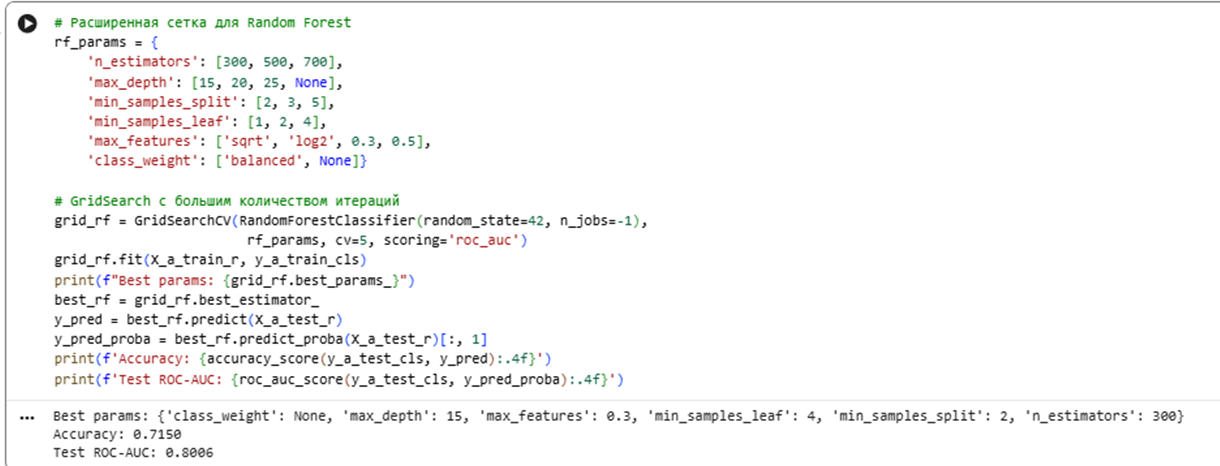

In [43]:
#обучаем модель RandomForecast с лучшими параметрами
best_rf = RandomForestClassifier(class_weight=None, max_depth=15, max_features=0.3, min_samples_leaf=4,
                                min_samples_split=2, n_estimators=300, random_state=42, n_jobs=-1)
best_rf.fit(X_a_train_r, y_a_train_cls)

y_pred_rf = best_rf.predict(X_a_test_r)
y_pred_proba = best_rf.predict_proba(X_a_test_r)[:, 1]
print(f'Accuracy:  {accuracy_score(y_a_test_cls, y_pred_rf):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_a_test_cls, y_pred_proba):.4f}')
print(f'F1-Score:  {f1_score(y_a_test_cls, y_pred_rf):.4f}')


Accuracy:  0.7150
ROC-AUC:   0.8006
F1-Score:  0.6952


In [69]:
#расширенная сетка для LightGMB
lgbm_params = {
    'num_leaves': [8, 10, 12, 15],
     'n_estimators': [100, 120, 140],
    'learning_rate': [0.08, 0.1, 0.15, 0.2],
    'max_depth': [5, 7, 10],
    'subsample': [0.8, 1.0],
    'min_child_samples': [10, 15, 20, 30]}
random_lgbm = RandomizedSearchCV(lgb.LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1), lgbm_params, n_iter=50,
                                 cv=сv, scoring='balanced_accuracy', random_state=42, n_jobs=-1, verbose=1)
random_lgbm.fit(X_a_train_r, y_a_train_cls)
print(f'Best params: {random_lgbm.best_params_}')
best_r_lgbm = random_lgbm.best_estimator_
y_pred_r_lgbm = best_r_lgbm.predict(X_a_test_r)
y_pred_proba_r_lgbm = best_r_lgbm.predict_proba(X_a_test_r)[:, 1]

print(f'Accuracy:  {accuracy_score(y_a_test_cls, y_pred_r_lgbm):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_a_test_cls, y_pred_proba_r_lgbm):.4f}')
print(f'F1-Score:  {f1_score(y_a_test_cls, y_pred_r_lgbm):.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.8, 'num_leaves': 10, 'n_estimators': 100, 'min_child_samples': 30, 'max_depth': 10, 'learning_rate': 0.1}
Accuracy:  0.7200
ROC-AUC:   0.7922
F1-Score:  0.6989


In [70]:
#обучаем LightGBM на лучших параметрах
best_lgbm = lgb.LGBMClassifier(subsample=0.8, learning_rate=0.1, n_estimators=100, num_leaves=10, min_child_samples=30, max_depth=10, random_state=42,verbose=-1, n_jobs=-1)
best_lgbm.fit(X_a_train_r, y_a_train_cls)

y_pred_lgbm = best_lgbm.predict(X_a_test_r)
y_pred_proba = best_lgbm.predict_proba(X_a_test_r)[:, 1]
print(f'Accuracy:  {accuracy_score(y_a_test_cls, y_pred_lgbm):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_a_test_cls, y_pred_proba):.4f}')
print(f'F1-Score:  {f1_score(y_a_test_cls, y_pred_lgbm):.4f}')

Accuracy:  0.7200
ROC-AUC:   0.7922
F1-Score:  0.6989


In [71]:
#обучаем ансамбль из полученных моделей
ensemble_soft = VotingClassifier(
    estimators=[('rf', best_rf), ('lgbm', best_lgbm)],
    voting='soft')
ensemble_soft.fit(X_a_train_r, y_a_train_cls)
y_pred_ens_soft = ensemble_soft.predict(X_a_test_r)
y_pred_proba_ens_soft = ensemble_soft.predict_proba(X_a_test_r)[:, 1]
print(f'Accuracy:  {accuracy_score(y_a_test_cls, y_pred_ens_soft):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_a_test_cls, y_pred_proba_ens_soft):.4f}')
print(f'F1-Score:  {f1_score(y_a_test_cls, y_pred_ens_soft):.4f}')

Accuracy:  0.7050
ROC-AUC:   0.7985
F1-Score:  0.6811


Ансамбль дал усредненный и не лучший результат из двух моделей, и не смогу превзойти RandomForecast по ROC-AUC, скорее всего из-за схожести моделей. Поэтому оставляем наибольший результат ROC-AUC как итоговый

In [44]:
#сохраняем полученную модель
with open('best_rf_ic50.pkl', 'wb') as f:
    pickle.dump(best_rf, f)
with open('scaler_ic50.pkl', 'wb') as f:
    pickle.dump(scaler_robust, f)
with open('median_ic50.pkl', 'wb') as f:
    pickle.dump(median_a_train, f)
print('Модель и компоненты сохранены в сессионное хранилище')

Модель и компоненты сохранены в сессионное хранилище


In [45]:
#проверяем загрузку
with open('best_rf_ic50.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('scaler_ic50.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)
with open('median_ic50.pkl', 'rb') as f:
    loaded_median = pickle.load(f)
print('Модель и компоненты загружены')

Модель и компоненты загружены
